# Exp FA-LOG — Operações sobre log(N!) antes do Sinal

**T. Bandeira · Junho de 2026**  
*Série analise-espectral-primos — irredutibilidade e redutibilidade nos logaritmos*

---

## Motivação

O fatorial em linguagem de logaritmos é:

$$\log(N!) = \sum_{m=2}^{N} \log m = \sum_{p \le N} \nu_p(N!) \cdot \log p$$

onde $\nu_p(N!) = \sum_k \lfloor N/p^k \rfloor$ é a multiplicidade de $p$ em $N!$.
Todo composto $m \le N$ contribui com $\log m = \sum_p v_p(m) \cdot \log p$ — uma soma
de logs de primos, ponderada pelos expoentes da fatoração.

**Ideia:** ao subtrair $k \cdot \log q$ do fatorial (para um primo $q$ e inteiro $k$),
estamos removendo $k$ fatores $q$ do fatorial — equivalente a passar de $N!$ para
$N!/q^k$. Isso é uma operação puramente nos logs, **antes** de qualquer sinal.

O sinal correspondente a $\log(N!)$ é:
$$S(t, \log(N!)) = -\frac{\cos(t \cdot \log(N!))}{\sqrt{\log(N!)}}$$

um **único pico** em $f_{N!} = \log(N!)/(2\pi)$. Após a subtração, o pico se desloca para
$f_{N!/q^k} = (\log(N!) - k\log q)/(2\pi)$.

**A questão central:** os compostos múltiplos de $q$ dentro do intervalo $[2,N]$ têm
$\log q$ como parte da sua fatoração. Existe alguma relação entre o deslocamento do pico
do fatorial e a distribuição espectral desses compostos?

Construímos também um **sinal acumulado** baseado na estrutura de log do fatorial:
$$R_{\log}(t) = \sum_{m=2}^{N} S(t, \log m) = \sum_{m=2}^{N} -\frac{\cos(t \cdot \log m)}{\sqrt{\log m}}$$

e comparamos antes e depois de subtrair contribuições de $\log q$.

## 1. Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime, primerange, factorint
import pandas as pd
import pickle

N     = 300
DT    = 0.05
T_MAX = 6500.0
W     = 3

t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)

print(f'N = {N}  |  T_MAX = {T_MAX}  |  pontos = {len(t):,}')
print(f'Resolução espectral: Δf = {freqs[1]:.6f}')

BG     = '#0D0D1A'
C_ORIG = '#7EB8F7'
C_REM  = '#F97B6B'
C_MULT = '#FFB347'
C_GRID = '#1E1E3A'
C_TEXT = '#CCCCDD'

def S_log(t, log_val):
    """Sinal associado a um valor logarítmico: pico em f = log_val/(2π)."""
    return -np.cos(t * log_val) / math.sqrt(log_val)

def f_de_log(log_val):
    return log_val / (2 * math.pi)

def amp_em_f(F, f_alvo, w=W):
    idx = np.argmin(np.abs(freqs - f_alvo))
    lo, hi = max(0, idx - w), min(len(F), idx + w)
    return np.max(F[lo:hi])

def espectro(sinal):
    return np.abs(np.fft.rfft(sinal)) * DT

def nu_p(p, N):
    total, pk = 0, p
    while pk <= N:
        total += N // pk; pk *= p
    return total

N = 300  |  T_MAX = 6500.0  |  pontos = 129,998
Resolução espectral: Δf = 0.000154


## 2. Estrutura de log(N!) e seus compostos

Calculamos $\log(N!)$ e decompõe cada natural $m \le N$ pela contribuição de cada primo $q$.

In [2]:
primos_N = list(primerange(2, N + 1))
log_fat  = sum(math.log(m) for m in range(2, N + 1))
f_fat    = f_de_log(log_fat)

print(f'log({N}!) = {log_fat:.6f}')
print(f'f_{{N!}}  = log({N}!)/(2π) = {f_fat:.6f}')
print(f'(Nota: essa frequência está MUITO acima da faixa [0, f_N={math.log(N)/(2*math.pi):.4f}]')
print(f' dos naturais — é um pico em outra escala)\n')

primos_teste = [3, 5, 7]
for q in primos_teste:
    nu_q = nu_p(q, N)
    deslocamento = nu_q * math.log(q)
    log_fat_sem_q = log_fat - deslocamento
    multiplos_q = [m for m in range(2, N+1) if m % q == 0]
    print(f'q={q}: ν_q={nu_q}  |  {nu_q}×log({q})={deslocamento:.4f}  |  '
          f'log(N!/q^ν)={log_fat_sem_q:.4f}  |  múltiplos de {q} ≤ N: {len(multiplos_q)}')

log(300!) = 1414.905850
f_{N!}  = log(300!)/(2π) = 225.189260
(Nota: essa frequência está MUITO acima da faixa [0, f_N=0.9078]
 dos naturais — é um pico em outra escala)

q=3: ν_q=148  |  148×log(3)=162.5946  |  log(N!/q^ν)=1252.3112  |  múltiplos de 3 ≤ N: 100
q=5: ν_q=74  |  74×log(5)=119.0984  |  log(N!/q^ν)=1295.8074  |  múltiplos de 5 ≤ N: 60
q=7: ν_q=48  |  48×log(7)=93.4037  |  log(N!/q^ν)=1321.5022  |  múltiplos de 7 ≤ N: 42


## 3. Sinal acumulado R_log — baseado em log(m) de cada natural

$$R_{\log}(t) = \sum_{m=2}^{N} S_{\log}(t, \log m) = -\sum_{m=2}^{N} \frac{\cos(t \cdot \log m)}{\sqrt{\log m}}$$

Diferença em relação ao $R_{nat}$ anterior: o fator de normalização é $1/\sqrt{\log m}$
(em vez de $1/\sqrt{m}$), e a frequência de cada pico continua sendo $f_m = \log m/(2\pi)$.
A operação de subtração de $k \cdot \log q$ agora tem sentido como operação nos **pesos
logarítmicos** de cada natural.

In [3]:
print('Construindo R_log...')
# R_log: cada natural m contribui com S_log(t, log(m)) = -cos(t*log(m))/sqrt(log(m))
R_log = sum(-np.cos(t * math.log(m)) / math.sqrt(math.log(m)) for m in range(2, N + 1))
F_log = espectro(R_log)
print('Pronto.')

# Amplitudes de referência em cada primo e composto
amp_ref_log = {m: amp_em_f(F_log, f_de_log(math.log(m))) for m in range(2, N+1)}
print(f'\nAmplitudes de referência nos primeiros primos (R_log):')
for p in primos_N[:8]:
    print(f'  p={p:>4}  f={f_de_log(math.log(p)):.4f}  amp={amp_ref_log[p]:.4f}')

Construindo R_log...
Pronto.

Amplitudes de referência nos primeiros primos (R_log):
  p=   2  f=0.1103  amp=3876.4606
  p=   3  f=0.1748  amp=1983.0041
  p=   5  f=0.2561  amp=2537.4997
  p=   7  f=0.3097  amp=2321.3206
  p=  11  f=0.3816  amp=1557.7863
  p=  13  f=0.4082  amp=1513.4892
  p=  17  f=0.4509  amp=1897.7708
  p=  19  f=0.4686  amp=1879.0654


## 4. Subtração de k×log(q) do sinal acumulado

Para cada primo $q$ e valores de $k$, subtraímos $k \cdot \log q$ do log de cada natural $m$
que tem $q$ como fator:

$$\log m - v_q(m) \cdot \log q = \log(m/q^{v_q(m)})$$

Isso desloca o pico de $m$ de $f_m = \log m/(2\pi)$ para $f_{m/q^{v_q}} = \log(m/q^{v_q})/(2\pi)$,
se $v_q(m) = k$, ou o reduz proporcionalmente se $k < v_q(m)$.

**Versão 1 (parcial):** subtrair $\min(k, v_q(m)) \cdot \log q$ do log de cada $m$ múltiplo de $q$.

**Versão 2 (total):** subtrair $v_q(m) \cdot \log q$ completamente — equivalente a remover todos
os fatores $q$ de cada $m$.

In [4]:
def v_q_m(m, q):
    """Expoente de q na fatoração de m."""
    v = 0
    while m % q == 0:
        v += 1; m //= q
    return v

def R_log_subtrair_klogq(k_remover, q):
    """
    Constrói R_log após subtrair k*log(q) dos logs de naturais que têm q como fator.
    Para m com v_q(m) >= k: subtrai k*log(q) -> log(m) - k*log(q) = log(m/q^k)
    Para m com v_q(m) < k:  subtrai v_q(m)*log(q) -> log(m/q^v_q(m))
    Para m sem fator q:      log(m) inalterado
    """
    R = np.zeros_like(t, dtype=float)
    for m in range(2, N + 1):
        vq = v_q_m(m, q)
        k_efetivo = min(k_remover, vq)  # nunca subtrair mais do que o m tem
        log_m_novo = math.log(m) - k_efetivo * math.log(q)
        if log_m_novo > 0:
            R += -np.cos(t * log_m_novo) / math.sqrt(log_m_novo)
    return R

# Testar para q=3, k=1 até zerar completamente
q_teste = 3
k_max = max(v_q_m(m, q_teste) for m in range(2, N+1))
print(f'q={q_teste}: expoente máximo em algum m<=N: k_max={k_max}')
print(f'(ex: 3^{k_max}={q_teste**k_max}  <=N={N}? {q_teste**k_max<=N})')

# Calcular para k=0 (original), k=1, k=2, k=k_max
k_vals_teste = list(range(0, k_max + 1))
print(f'\nCalculando R_log modificado para k = {k_vals_teste}...')

espectros_por_k = {}
for k in k_vals_teste:
    if k == 0:
        espectros_por_k[k] = F_log
    else:
        R_k = R_log_subtrair_klogq(k, q_teste)
        espectros_por_k[k] = espectro(R_k)
    print(f'  k={k} pronto.')
print('Concluído.')

q=3: expoente máximo em algum m<=N: k_max=5
(ex: 3^5=243  <=N=300? True)

Calculando R_log modificado para k = [0, 1, 2, 3, 4, 5]...
  k=0 pronto.
  k=1 pronto.
  k=2 pronto.
  k=3 pronto.
  k=4 pronto.
  k=5 pronto.
Concluído.


## 5. Tabela — efeito em múltiplos de q vs não-múltiplos

In [5]:
q = q_teste
resultados = []
for k in k_vals_teste:
    F_k = espectros_por_k[k]
    for m in range(2, min(N+1, 101)):  # focar nos primeiros 100 para visualização clara
        vq = v_q_m(m, q)
        amp_orig = amp_ref_log[m]
        amp_k    = amp_em_f(F_k, f_de_log(math.log(m)))
        delta    = 100*(amp_k - amp_orig)/amp_orig if amp_orig > 1e-12 else np.nan
        resultados.append({
            'k': k, 'm': m, 'v_q_m': vq,
            'eh_multiplo': vq > 0, 'eh_primo': isprime(m),
            'amp_orig': amp_orig, 'amp_k': amp_k, 'delta_%': delta
        })

df = pd.DataFrame(resultados)
df.to_csv('fat_log_subtracao_klogq.csv', index=False)

print(f'q={q} — Delta% médio por k, múltiplos vs não-múltiplos:')
print(df.groupby(['k','eh_multiplo'])['delta_%'].mean().unstack())

print(f'\nPara k={k_max} (completo): top múltiplos mais afetados:')
sub = df[df['k']==k_max].sort_values('delta_%')
print(sub[sub['eh_multiplo']][['m','v_q_m','amp_orig','amp_k','delta_%']].head(15).to_string(index=False))

q=3 — Delta% médio por k, múltiplos vs não-múltiplos:
eh_multiplo       False      True 
k                                 
0              0.000000   0.000000
1             99.921777   0.301245
2            131.769184 -63.107886
3            142.480935 -86.538168
4            144.004072 -92.479706
5            144.013384 -95.469041

Para k=5 (completo): top múltiplos mais afetados:
 m  v_q_m    amp_orig     amp_k    delta_%
 3      1 1983.004057 12.772436 -99.355905
 6      1 1706.939903 21.677315 -98.730048
24      1 1484.898515 21.978479 -98.519867
12      1 1566.011369 25.250544 -98.387589
 9      2 2180.009368 37.633932 -98.273680
18      2 1892.225710 33.108434 -98.250291
15      1 1392.503752 25.631198 -98.159344
69      1 1530.425365 29.409166 -98.078367
63      2 1613.507284 35.190290 -97.819019
45      2 1648.287430 36.226602 -97.802167
39      1 1649.681289 36.531326 -97.785553
42      1 1209.723585 33.037002 -97.269045
27      3 1144.785150 32.493770 -97.161584
48      1 142

## 6. Visualização — espectro local antes/depois para múltiplos de q

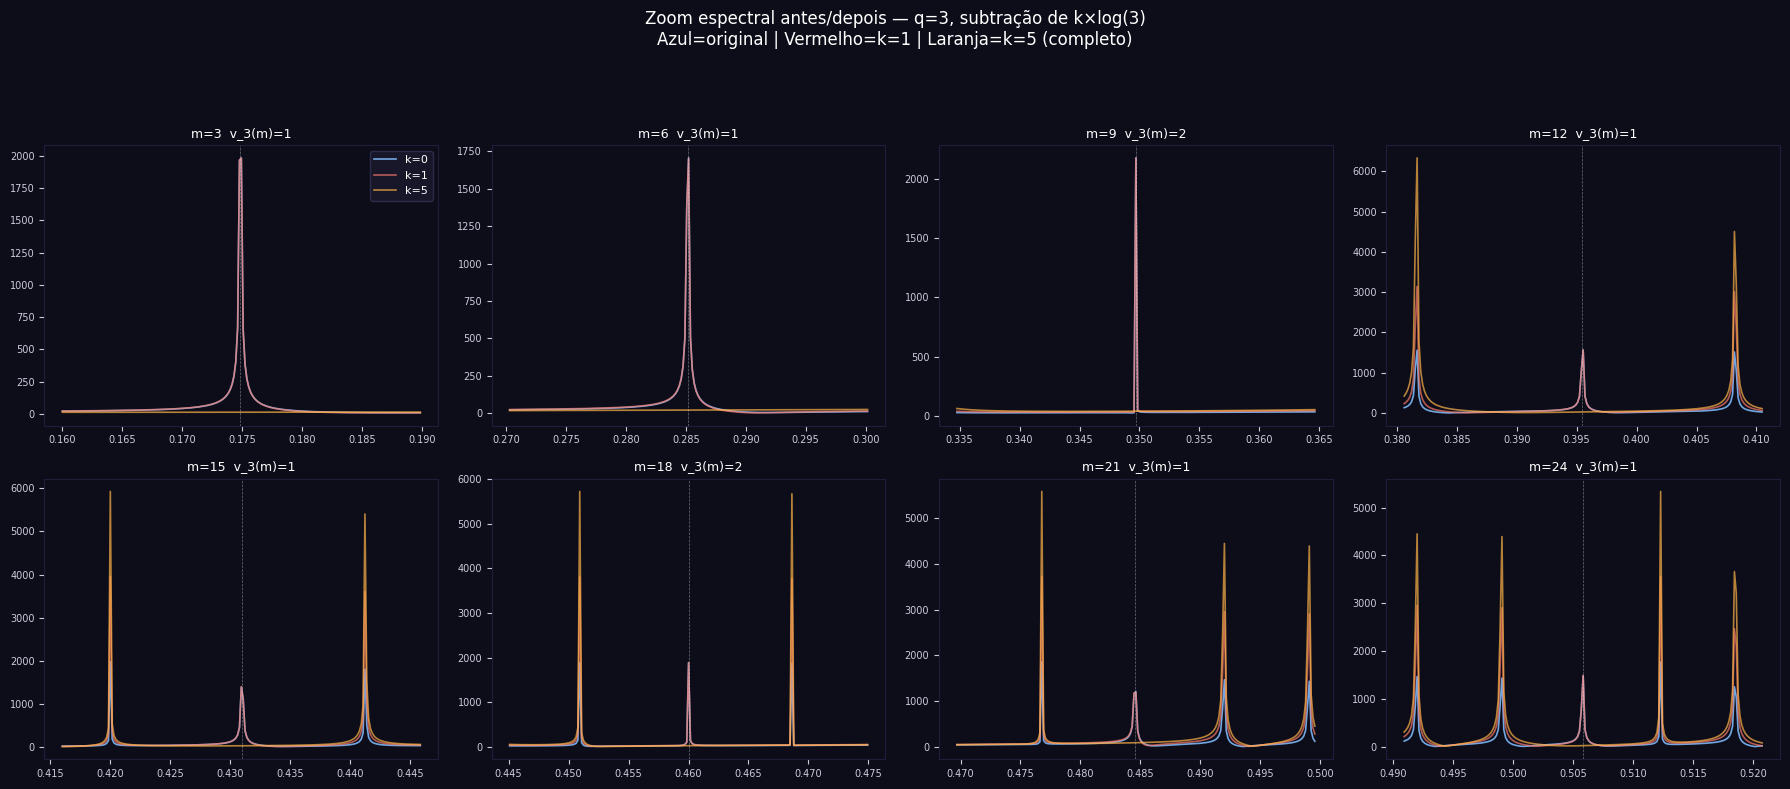

Figura salva: zoom_multiplos_subtracao_log.png


In [6]:
# Zoom em torno dos primeiros múltiplos de q: 3,6,9,12,15,18,21,27
multiplos_plot = [m for m in range(2, 60) if m % q_teste == 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Zoom espectral antes/depois — q={q_teste}, subtração de k×log({q_teste})\n'
             f'Azul=original | Vermelho=k=1 | Laranja=k={k_max} (completo)',
             color='white', fontsize=12)

cores_k = {0: C_ORIG, 1: C_REM, k_max: C_MULT}
k_plot  = [0, 1, k_max]

for ax, m in zip(axes.flat, multiplos_plot[:8]):
    ax.set_facecolor(BG)
    f_m_orig = f_de_log(math.log(m))
    fspan = 0.015
    mask = (freqs > f_m_orig - fspan) & (freqs < f_m_orig + fspan)

    for k in k_plot:
        F_k = espectros_por_k[k]
        label = f'k={k}'
        ax.plot(freqs[mask], F_k[mask], color=cores_k[k], lw=1.2,
                alpha=0.9 if k==0 else 0.7, label=label)

    ax.axvline(f_m_orig, color='white', lw=0.5, ls='--', alpha=0.4)
    vq = v_q_m(m, q_teste)
    ax.set_title(f'm={m}  v_{q_teste}(m)={vq}', color='white', fontsize=9)
    ax.tick_params(colors=C_TEXT, labelsize=7)
    for s in ax.spines.values(): s.set_edgecolor(C_GRID)

axes[0][0].legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig('zoom_multiplos_subtracao_log.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: zoom_multiplos_subtracao_log.png')

## 7. Espectro completo — antes e depois, para cada q

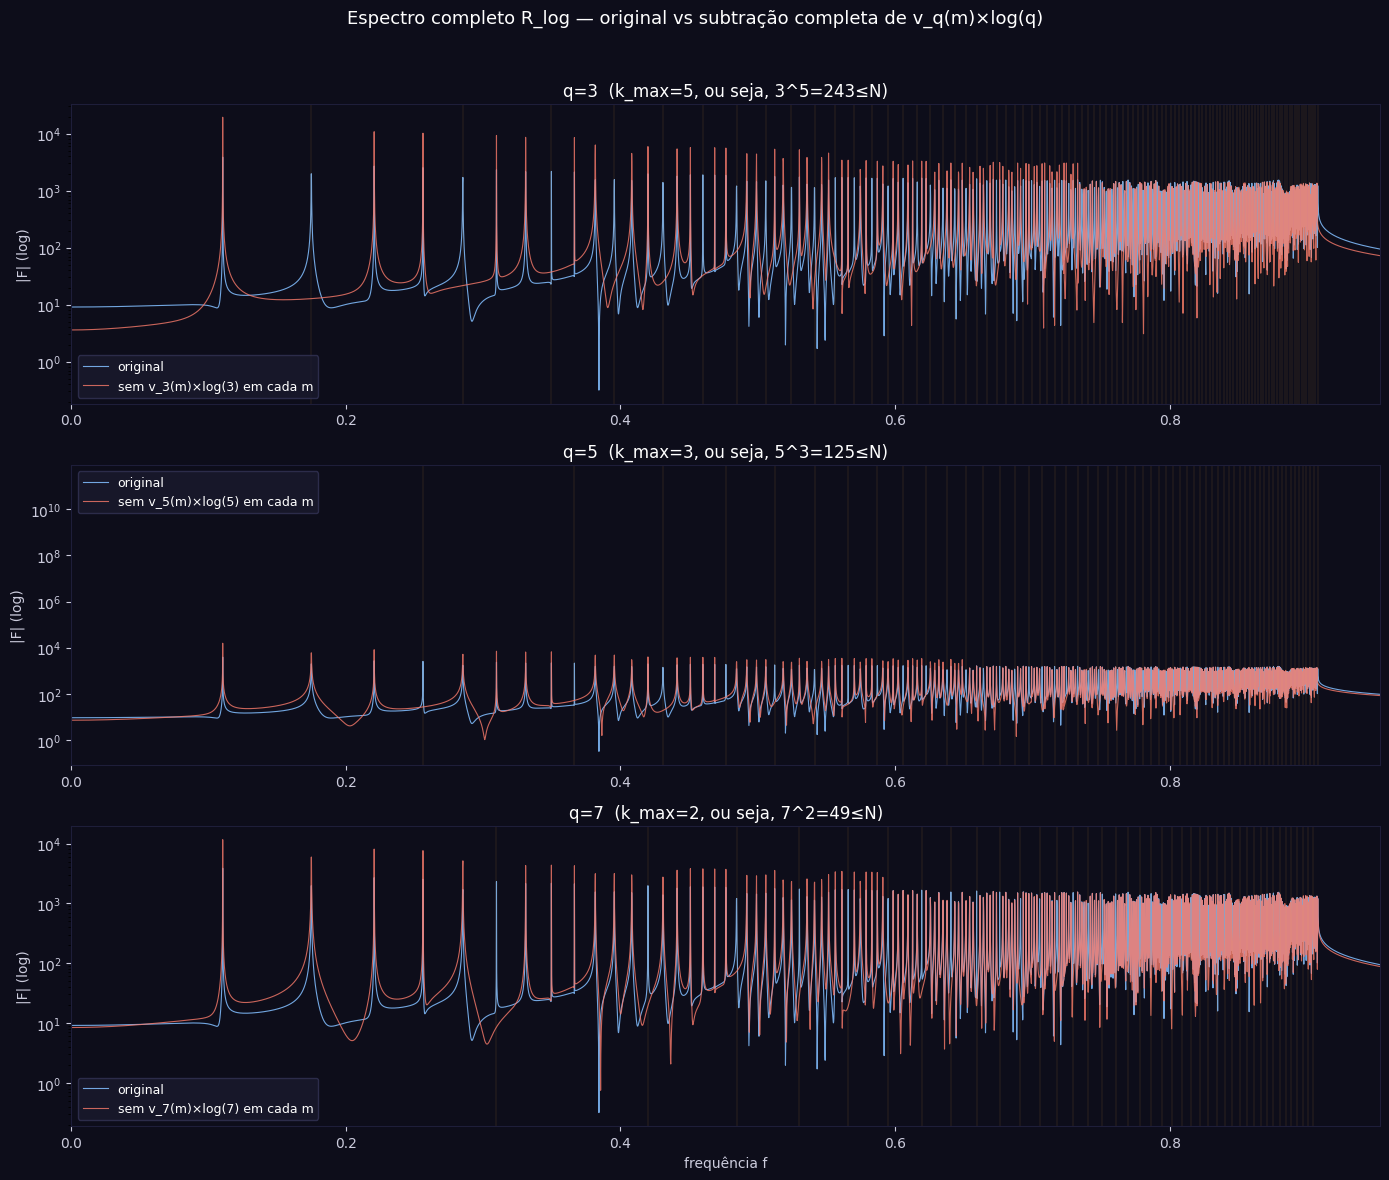

Figura salva: espectro_completo_subtracao_log.png


In [7]:
# Calcular para os três primos teste (q=3,5,7) -- subtração completa (k=k_max)
primos_teste = [3, 5, 7]
f_lim = f_de_log(math.log(N)) * 1.05
mask_full = freqs <= f_lim

fig, axes = plt.subplots(len(primos_teste), 1, figsize=(14, 4*len(primos_teste)))
fig.patch.set_facecolor(BG)
fig.suptitle('Espectro completo R_log — original vs subtração completa de v_q(m)×log(q)',
             color='white', fontsize=13)

for ax, q in zip(axes, primos_teste):
    ax.set_facecolor(BG)
    k_max_q = max(v_q_m(m, q) for m in range(2, N+1))
    R_q_zero = R_log_subtrair_klogq(k_max_q, q)
    F_q_zero = espectro(R_q_zero)

    ax.semilogy(freqs[mask_full], F_log[mask_full],   color=C_ORIG, lw=0.8, alpha=0.9, label='original')
    ax.semilogy(freqs[mask_full], F_q_zero[mask_full], color=C_REM,  lw=0.8, alpha=0.8,
                label=f'sem v_{q}(m)×log({q}) em cada m')

    # Marcar posições dos múltiplos de q
    for m in range(2, N+1):
        if m % q == 0 and f_de_log(math.log(m)) <= f_lim:
            ax.axvline(f_de_log(math.log(m)), color=C_MULT, lw=0.3, alpha=0.3)

    ax.set_title(f'q={q}  (k_max={k_max_q}, ou seja, {q}^{k_max_q}={q**k_max_q}≤N)',
                 color='white')
    ax.set_ylabel('|F| (log)', color=C_TEXT)
    ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=9)
    ax.tick_params(colors=C_TEXT)
    ax.set_xlim(0, f_lim)
    for s in ax.spines.values(): s.set_edgecolor(C_GRID)

axes[-1].set_xlabel('frequência f', color=C_TEXT)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('espectro_completo_subtracao_log.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: espectro_completo_subtracao_log.png')

## 8. Exportar artefatos

In [8]:
import zipfile, os

with open('espectros_log.pkl', 'wb') as f:
    pickle.dump({
        'freqs': freqs, 'N': N, 'T_MAX': T_MAX,
        'F_log': F_log, 'log_fat': log_fat
    }, f)

arquivos = [
    'fat_log_subtracao_klogq.csv',
    'zoom_multiplos_subtracao_log.png',
    'espectro_completo_subtracao_log.png',
    'espectros_log.pkl',
]

with zipfile.ZipFile('exp_fat_log_resultados.zip', 'w') as zf:
    for arq in arquivos:
        if os.path.exists(arq): zf.write(arq)

print('Pacote: exp_fat_log_resultados.zip')
for arq in arquivos:
    print(f'  [{"OK" if os.path.exists(arq) else "FALTANDO"}] {arq}')

Pacote: exp_fat_log_resultados.zip
  [OK] fat_log_subtracao_klogq.csv
  [OK] zoom_multiplos_subtracao_log.png
  [OK] espectro_completo_subtracao_log.png
  [OK] espectros_log.pkl


---

## Notas para interpretação

- **Seção 4 (`R_log_subtrair_klogq`):** a operação é nos logs de cada $m$ individualmente —
  ao subtrair $k \cdot \log q$ do $\log m$ (se $m$ tem fator $q$), deslocamos o pico de $m$
  para $f_{m/q^k}$. Isso é uma operação de fatoração nos logs antes do sinal.
- **Seção 5:** a coluna `delta_%` por `eh_multiplo` é o teste central — se múltiplos
  sofrem mais variação que não-múltiplos, há evidência de propagação via estrutura de logs.
- **Seção 6 (zoom):** os picos dos múltiplos de $q$ devem se **deslocar** (não só cair),
  porque o $\log m$ de cada múltiplo foi alterado — o pico vai para uma frequência nova
  $f_{m/q^{v_q(m)}}$. Isso é diferente de todos os experimentos anteriores, onde só
  havia queda no pico original.
- **Seção 7 (espectro completo):** as linhas verticais laranja marcam as posições originais
  dos múltiplos de $q$ — verificar se no espectro vermelho (após operação) essas posições
  ficam vazias (picos deslocaram) e se aparecem novos picos nas posições $f_{m/q^k}$.